In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [3]:
df.head()

,index,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [4]:
df=df.drop(['day','month','year','index'],axis=1)

In [5]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'0','1')

In [8]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [9]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [10]:
##independent and dependent features
X=df.drop('FWI',axis=1) ##independent
Y=df['FWI']##dependent

In [11]:
X

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0
...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0,1


In [12]:
Y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [13]:
##Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [14]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  243 non-null    int64  
 1   RH           243 non-null    int64  
 2   Ws           243 non-null    int64  
 3   Rain         243 non-null    float64
 4   FFMC         243 non-null    float64
 5   DMC          243 non-null    float64
 6   DC           243 non-null    float64
 7   ISI          243 non-null    float64
 8   BUI          243 non-null    float64
 9   FWI          243 non-null    float64
 10  Classes      243 non-null    str    
 11  Region       243 non-null    int64  
dtypes: float64(7), int64(4), str(1)
memory usage: 22.9 KB


In [16]:
x_train.info()


<class 'pandas.DataFrame'>
Index: 182 entries, 97 to 102
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  182 non-null    int64  
 1   RH           182 non-null    int64  
 2   Ws           182 non-null    int64  
 3   Rain         182 non-null    float64
 4   FFMC         182 non-null    float64
 5   DMC          182 non-null    float64
 6   DC           182 non-null    float64
 7   ISI          182 non-null    float64
 8   BUI          182 non-null    float64
 9   Classes      182 non-null    str    
 10  Region       182 non-null    int64  
dtypes: float64(6), int64(4), str(1)
memory usage: 17.1 KB


<Axes: >

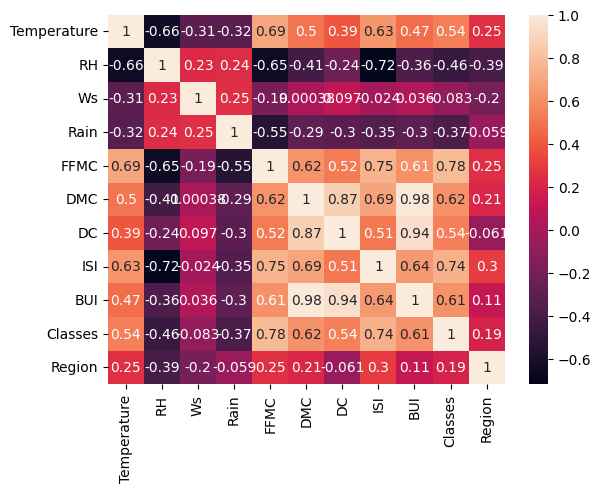

In [17]:
##chech for multi colinearity
sns.heatmap(x_train.corr(),annot=True)

In [18]:
def correlation(dataset,threshold):
    col_cor=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                col_cor.add(corr_matrix.columns[i])

    return col_cor                 

In [19]:
corr_features=correlation(x_train,0.85)

In [20]:
##drop features having correlation is morethan 0.85

x_train.drop(corr_features,inplace=True,axis=1)

In [21]:
x_test.drop(corr_features,inplace=True,axis=1)

In [22]:
x_test.shape


(61, 9)

In [23]:
x_train.shape

(182, 9)

In [24]:
##Feature scaling or standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [25]:
x_test_scaled

array([[-3.01758418e-01,  1.15223531e-01, -2.19053977e-01,
        -3.84060174e-01,  6.33218240e-01, -4.25075679e-02,
         2.03772218e-01,  9.05538514e-01, -9.89070710e-01],
       [ 2.39325642e-01, -5.52632606e-01, -9.78441098e-01,
        -3.84060174e-01,  7.37980727e-01, -3.83352062e-01,
         3.65823283e-01,  9.05538514e-01, -9.89070710e-01],
       [-1.11338451e+00, -2.85490151e-01,  9.20026704e-01,
         6.45241658e-01, -9.73139891e-01, -9.14435344e-01,
        -8.37984627e-01, -1.10431526e+00,  1.01105006e+00],
       [ 5.09867672e-01, -2.85490151e-01, -9.78441098e-01,
        -2.90487280e-01,  1.30358303e-01,  3.14190159e-01,
        -6.29633258e-01, -1.10431526e+00,  1.01105006e+00],
       [-5.72300448e-01,  1.82009145e-01, -5.98747538e-01,
        -3.84060174e-01,  5.42424085e-01,  1.00171523e-01,
        -7.40296073e-02,  9.05538514e-01,  1.01105006e+00],
       [ 1.86257782e+00,  1.15223531e-01, -2.49721534e+00,
         1.77377189e-01, -2.67739147e-01, -2.406729

Text(0.5, 1.0, 'after sts')

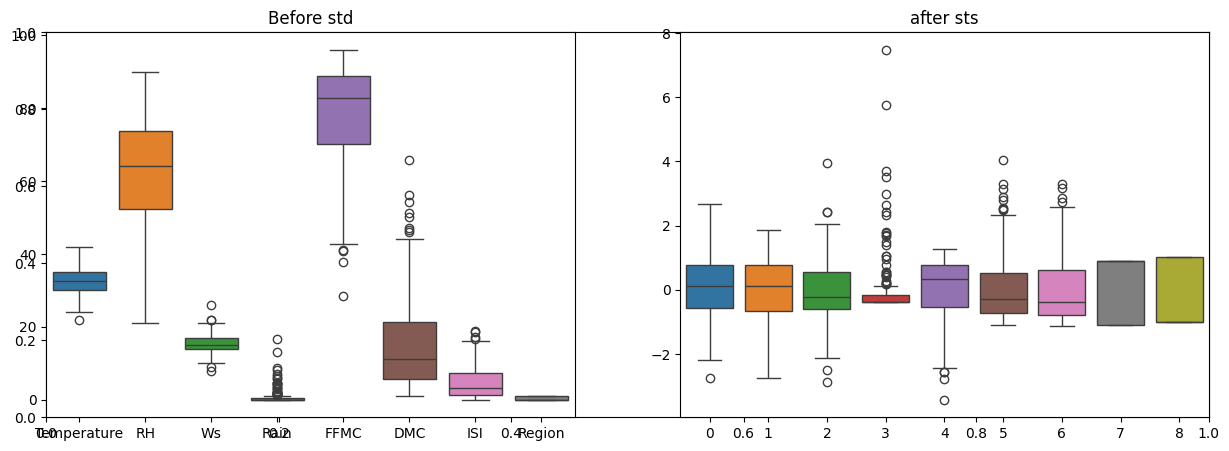

In [26]:
##box plots to understand the effect of standard scalar
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title("Before std")
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title("after sts")

In [27]:
#Linear Regression


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
linreg=LinearRegression()
linreg.fit(x_train_scaled,y_train)
y_pred=linreg.predict(x_test_scaled)
mae=mean_absolute_error(y_test,y_pred)*100
score=r2_score(y_test,y_pred)*100


In [28]:
print(f"Mean absolute Error : {mae}")
print(f"R2 Score : {score}")

Mean absolute Error : 54.682364652499786
R2 Score : 98.47657384266951


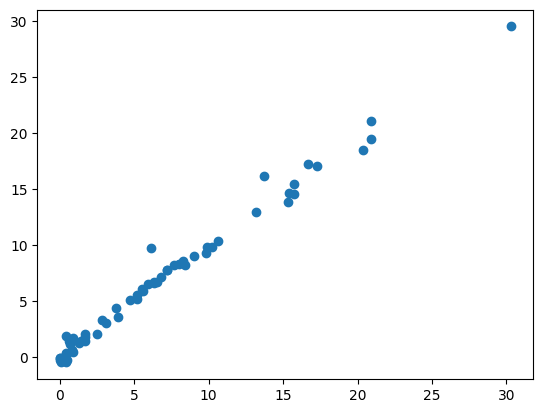

In [29]:
plt.scatter(y_test,y_pred)

In [30]:
#Lasso Regression in order to overcome overfiiitting
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(x_train_scaled,y_train)
y_pred=lasso.predict(x_test_scaled)
maeLasso=mean_absolute_error(y_test,y_pred)
scoreLasso=r2_score(y_test,y_pred)


In [31]:
print(f"Mean absolute Error : {maeLasso}")
print(f"R2 Score : {scoreLasso}")

Mean absolute Error : 1.1331759949144087
R2 Score : 0.9492020263112388


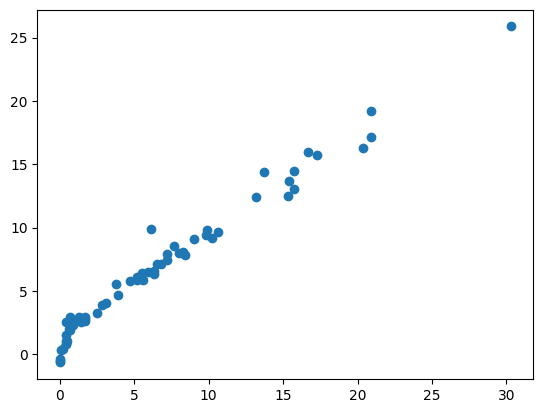

In [32]:
plt.scatter(y_test,y_pred)

Mean absolute Error : 0.5642305340105715
R2 Score : 0.9842993364555512


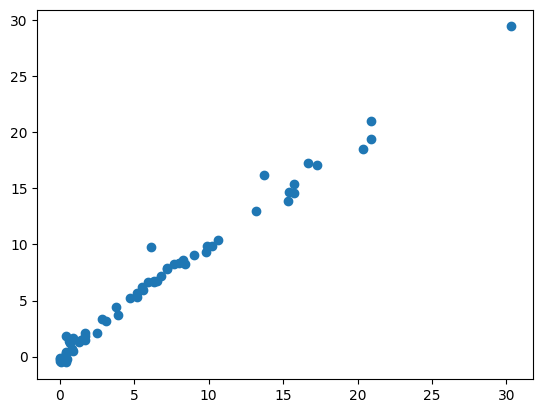

In [33]:
##ridge regression

#Lasso Regression in order to overcome overfiiitting
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
maeridge=mean_absolute_error(y_test,y_pred)
scoreridge=r2_score(y_test,y_pred)


print(f"Mean absolute Error : {maeridge}")
print(f"R2 Score : {scoreridge}")



plt.scatter(y_test,y_pred)


Mean absolute Error : 1.8822353634895999
R2 Score : 0.8753460589519703


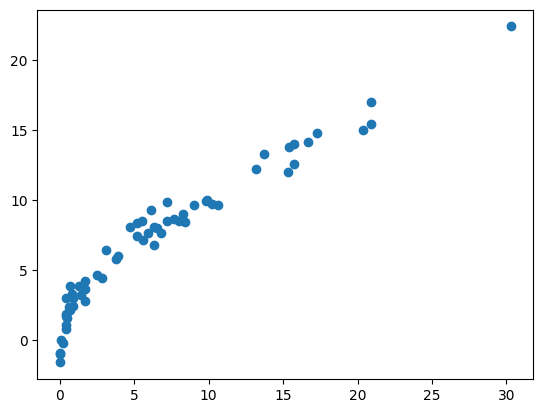

In [34]:
##Elastic Net
##ridge regression

#Lasso Regression in order to overcome overfiiitting
from sklearn.linear_model import ElasticNet
ridge=ElasticNet()
ridge.fit(x_train_scaled,y_train)
y_pred=ridge.predict(x_test_scaled)
maeridge=mean_absolute_error(y_test,y_pred)
scoreridge=r2_score(y_test,y_pred)


print(f"Mean absolute Error : {maeridge}")
print(f"R2 Score : {scoreridge}")



plt.scatter(y_test,y_pred)
